## Many well

## Ground truth

In [1]:
import jax
import jax.numpy as jnp
from jax import random
import numpy as np

# ---------------------------
# 1. Parameters
# ---------------------------
d = 5
delta = 4.0
N_GRID = 20001
N_SAMPLES = 4000

# ---------------------------
# 2. Compute normalized 1D PDF (host-side)
# ---------------------------
x_grid = jnp.linspace(-5.0, 5.0, N_GRID)
U_1d = (x_grid**2 - delta) ** 2
unnorm = jnp.exp(-U_1d)

# use modern numpy trapezoid for integration
Z_1d = np.trapezoid(np.array(unnorm), np.array(x_grid))
pdf_1d = unnorm / Z_1d
cdf_1d = jnp.cumsum(pdf_1d)
cdf_1d = cdf_1d / cdf_1d[-1]

# ---------------------------
# 3. Inverse-CDF sampler (no JIT here due to dynamic n)
# ---------------------------
def sample_1d(key, n):
    u = random.uniform(key, shape=(n,))
    idx = jnp.searchsorted(cdf_1d, u, side="right")
    idx = jnp.clip(idx, 1, len(x_grid) - 1)
    x0, x1 = x_grid[idx - 1], x_grid[idx]
    c0, c1 = cdf_1d[idx - 1], cdf_1d[idx]
    slope = (x1 - x0) / (c1 - c0)
    return x0 + slope * (u - c0)

# ---------------------------
# 4. Generate 5D samples (coordinates independent)
# ---------------------------
def sample_5d(key, n):
    subkeys = random.split(key, d)
    samples = [sample_1d(k, n) for k in subkeys]
    return jnp.stack(samples, axis=1)

# ---------------------------
# 5. Draw samples
# ---------------------------
rng = random.PRNGKey(42)
samples_5d = sample_5d(rng, N_SAMPLES)
ref_samples_5d   = jnp.array(samples_5d)

print("5D samples shape:", samples_5d.shape)
print("Example samples:\n", np.array(samples_5d[:5]))


5D samples shape: (4000, 5)
Example samples:
 [[ 1.6810433  1.9631404  1.9049636 -1.8410207  1.9777675]
 [-1.9249195  2.0174553  1.9574592 -2.1475084  1.7762471]
 [ 2.1310716 -2.0457478 -2.0996935 -2.200176   2.1933317]
 [ 1.9357337 -1.9724945 -1.8825396  1.8541056  2.0106044]
 [ 1.8495694 -2.117268  -1.7942214 -1.8868984  2.004968 ]]


## PPO Run

[Iter 0001] σ=0.100 log ν(x_T) quartiles=(-61.0,-50.6,-40.9) IQR=20.1 | actor_loss=-0.001 critic_loss=892.707 ratio=1.001 H=-4.418
   ↳ modes_hit=32/32 | top mode mass=0.068 | bottom mode mass=0.014
   ↳ MMD²=3.7426e-02


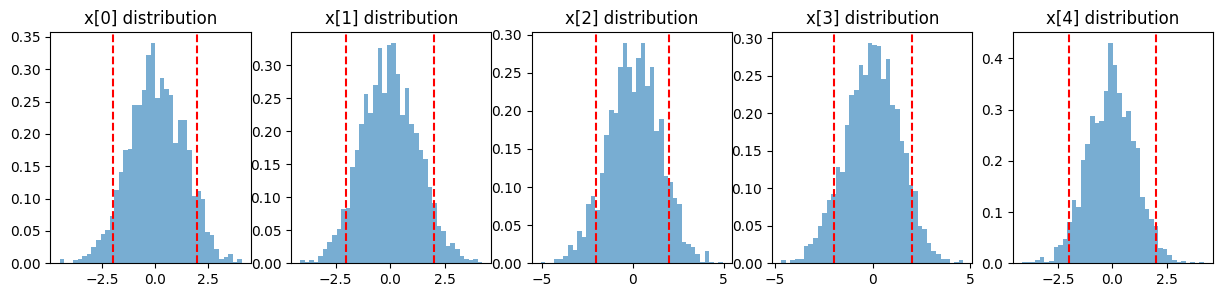

[Iter 0002] σ=0.100 log ν(x_T) quartiles=(-61.3,-51.2,-41.3) IQR=20.0 | actor_loss=-0.000 critic_loss=695.081 ratio=1.001 H=-4.418
   ↳ modes_hit=32/32 | top mode mass=0.064 | bottom mode mass=0.014
   ↳ MMD²=4.0286e-02


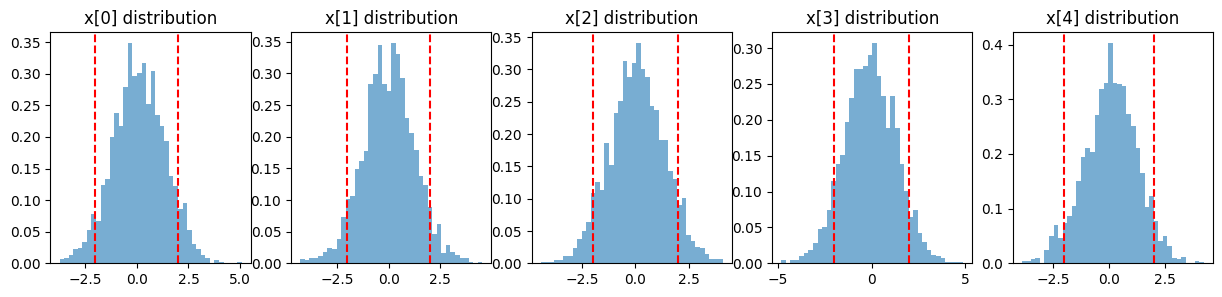

[Iter 0003] σ=0.100 log ν(x_T) quartiles=(-60.4,-50.9,-41.1) IQR=19.3 | actor_loss=0.000 critic_loss=992.029 ratio=1.002 H=-4.418
   ↳ modes_hit=32/32 | top mode mass=0.066 | bottom mode mass=0.014
   ↳ MMD²=4.3141e-02


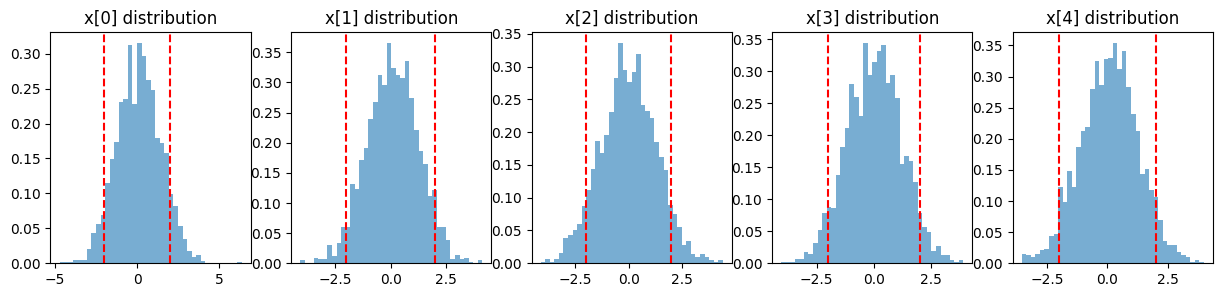

[Iter 0004] σ=0.100 log ν(x_T) quartiles=(-59.4,-49.5,-40.7) IQR=18.6 | actor_loss=-0.003 critic_loss=516.814 ratio=1.000 H=-4.418
   ↳ modes_hit=32/32 | top mode mass=0.051 | bottom mode mass=0.015
   ↳ MMD²=4.1104e-02


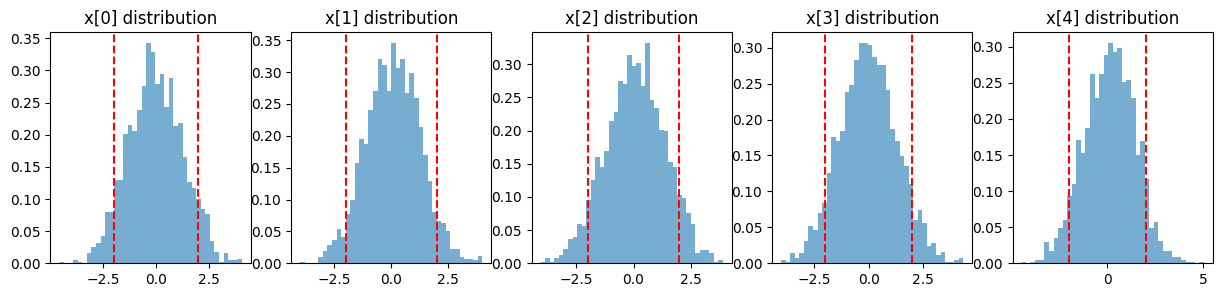

[Iter 0005] σ=0.100 log ν(x_T) quartiles=(-59.2,-49.9,-40.4) IQR=18.8 | actor_loss=-0.000 critic_loss=449.683 ratio=1.001 H=-4.418
   ↳ modes_hit=32/32 | top mode mass=0.054 | bottom mode mass=0.017
   ↳ MMD²=4.4511e-02


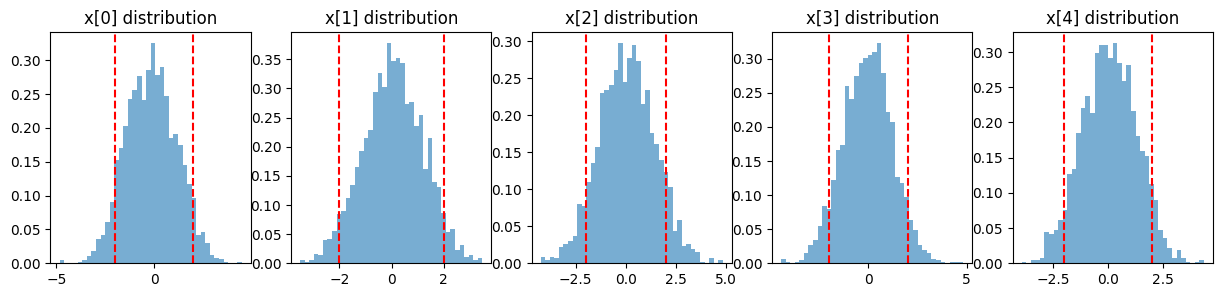

[Iter 0100] σ=0.100 log ν(x_T) quartiles=(-21.0,-14.2,-8.7) IQR=12.3 | actor_loss=-0.000 critic_loss=15.494 ratio=0.999 H=-4.418
   ↳ modes_hit=32/32 | top mode mass=0.039 | bottom mode mass=0.021
   ↳ MMD²=3.3557e-03


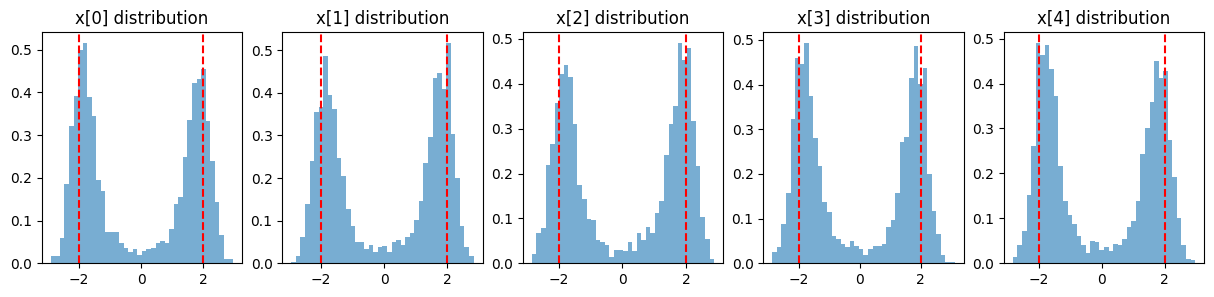

[Iter 0200] σ=0.100 log ν(x_T) quartiles=(-18.3,-12.0,-7.0) IQR=11.3 | actor_loss=0.000 critic_loss=14.938 ratio=0.998 H=-4.418
   ↳ modes_hit=32/32 | top mode mass=0.042 | bottom mode mass=0.021
   ↳ MMD²=2.5246e-03


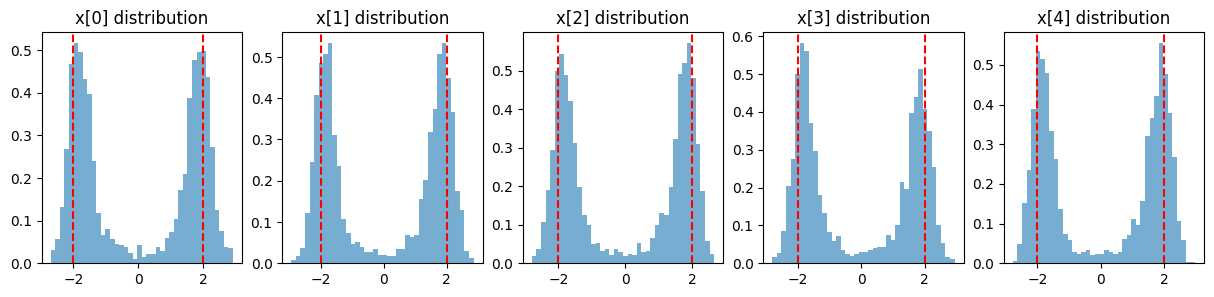

[Iter 0300] σ=0.100 log ν(x_T) quartiles=(-15.5,-10.0,-6.4) IQR=9.1 | actor_loss=-0.003 critic_loss=10.728 ratio=0.998 H=-4.418
   ↳ modes_hit=32/32 | top mode mass=0.042 | bottom mode mass=0.021
   ↳ MMD²=3.4914e-03


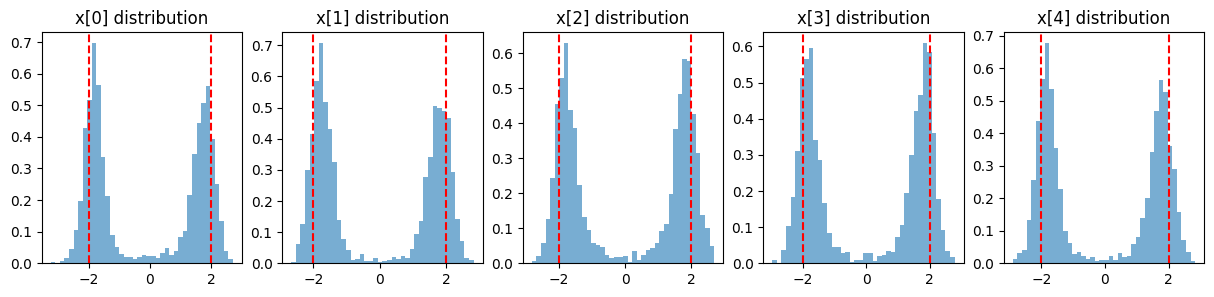

[Iter 0400] σ=0.100 log ν(x_T) quartiles=(-14.4,-9.3,-5.8) IQR=8.5 | actor_loss=-0.001 critic_loss=11.362 ratio=0.999 H=-4.418
   ↳ modes_hit=32/32 | top mode mass=0.052 | bottom mode mass=0.019
   ↳ MMD²=2.5134e-03


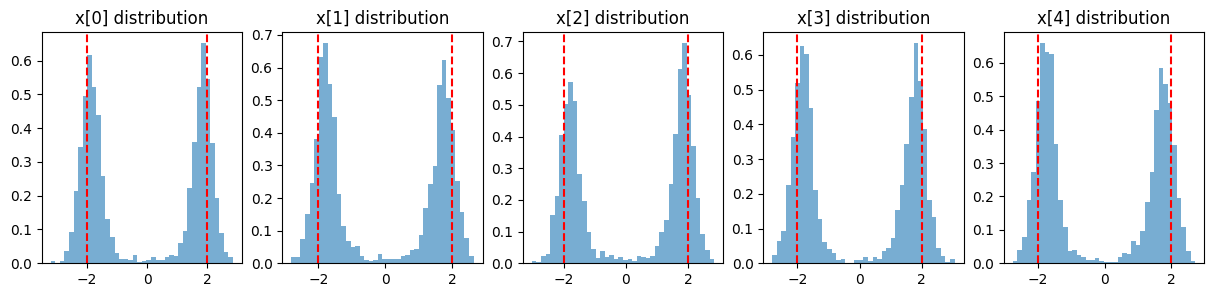

[Iter 0500] σ=0.100 log ν(x_T) quartiles=(-13.4,-8.7,-5.6) IQR=7.8 | actor_loss=0.000 critic_loss=11.147 ratio=1.004 H=-4.418
   ↳ modes_hit=32/32 | top mode mass=0.040 | bottom mode mass=0.016
   ↳ MMD²=3.2330e-03


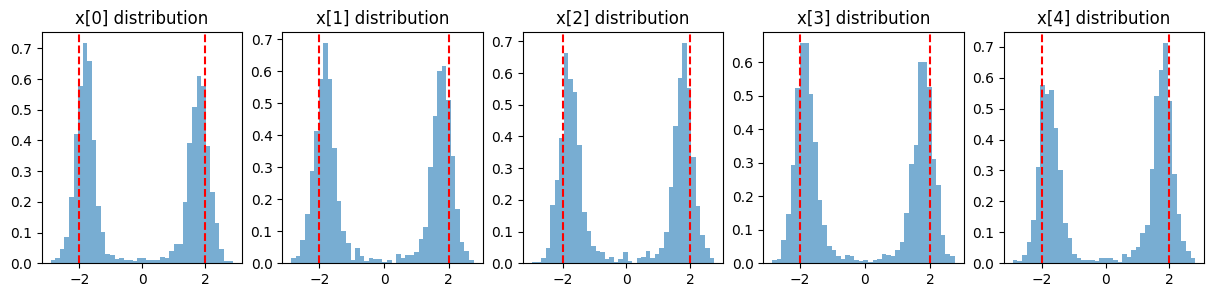

[Iter 0600] σ=0.100 log ν(x_T) quartiles=(-14.1,-9.2,-5.9) IQR=8.1 | actor_loss=-0.002 critic_loss=11.752 ratio=1.002 H=-4.418
   ↳ modes_hit=32/32 | top mode mass=0.044 | bottom mode mass=0.018
   ↳ MMD²=3.1161e-03


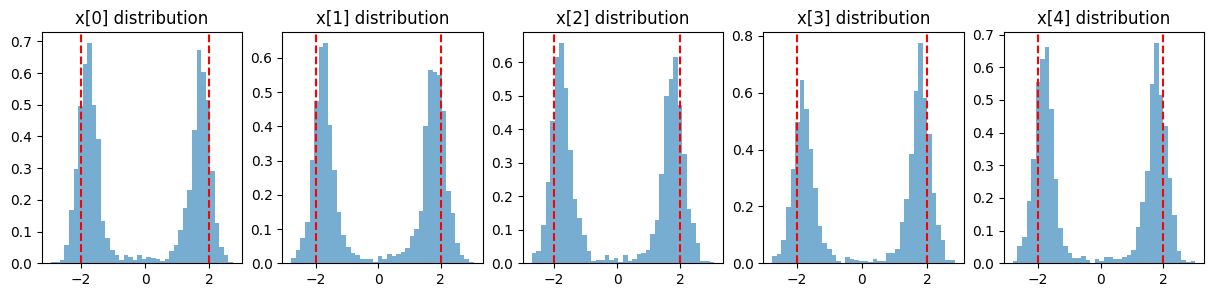

[Iter 0700] σ=0.100 log ν(x_T) quartiles=(-13.0,-8.4,-5.5) IQR=7.6 | actor_loss=-0.005 critic_loss=12.307 ratio=0.998 H=-4.418
   ↳ modes_hit=32/32 | top mode mass=0.041 | bottom mode mass=0.021
   ↳ MMD²=1.7630e-03


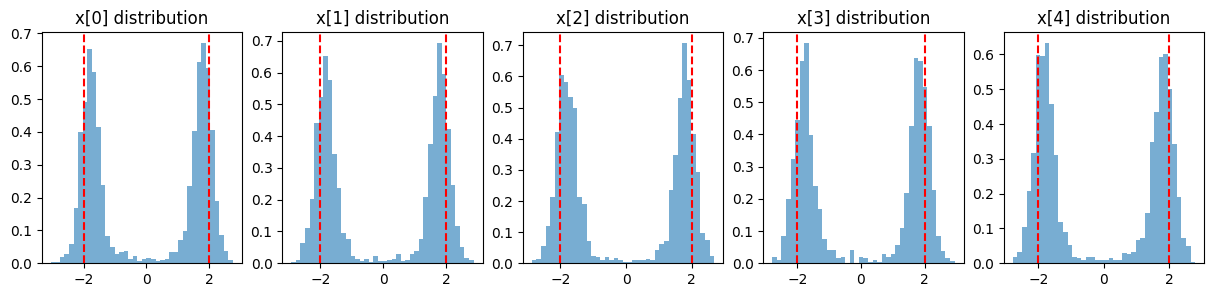

[Iter 0800] σ=0.100 log ν(x_T) quartiles=(-13.3,-8.6,-5.3) IQR=8.0 | actor_loss=-0.003 critic_loss=11.789 ratio=1.001 H=-4.418
   ↳ modes_hit=32/32 | top mode mass=0.048 | bottom mode mass=0.019
   ↳ MMD²=3.1457e-03


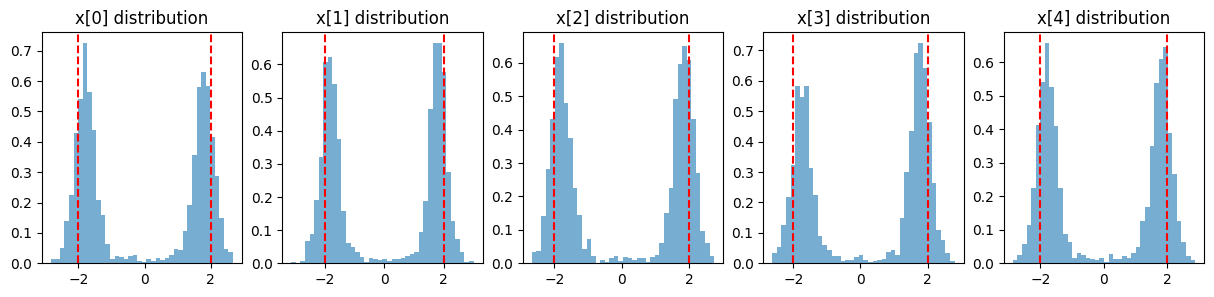

[Iter 0900] σ=0.100 log ν(x_T) quartiles=(-13.2,-8.4,-5.3) IQR=7.9 | actor_loss=-0.003 critic_loss=12.739 ratio=1.001 H=-4.418
   ↳ modes_hit=32/32 | top mode mass=0.041 | bottom mode mass=0.017
   ↳ MMD²=2.6327e-03


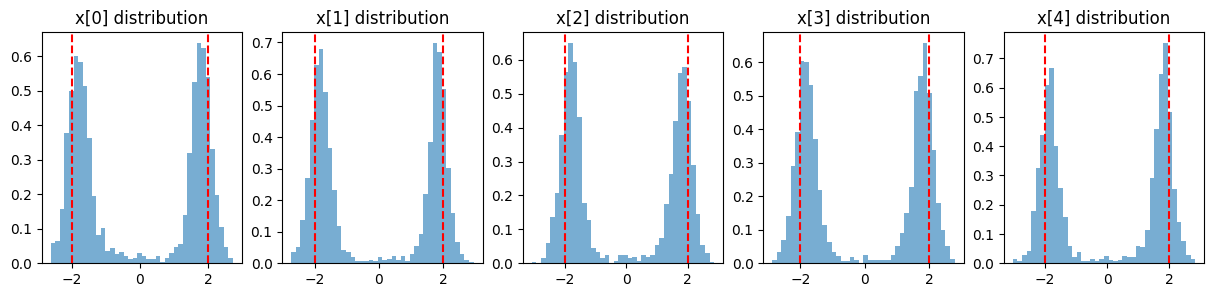

[Iter 1000] σ=0.100 log ν(x_T) quartiles=(-13.2,-8.6,-5.3) IQR=7.9 | actor_loss=-0.003 critic_loss=11.891 ratio=1.001 H=-4.418
   ↳ modes_hit=32/32 | top mode mass=0.043 | bottom mode mass=0.021
   ↳ MMD²=2.6920e-03


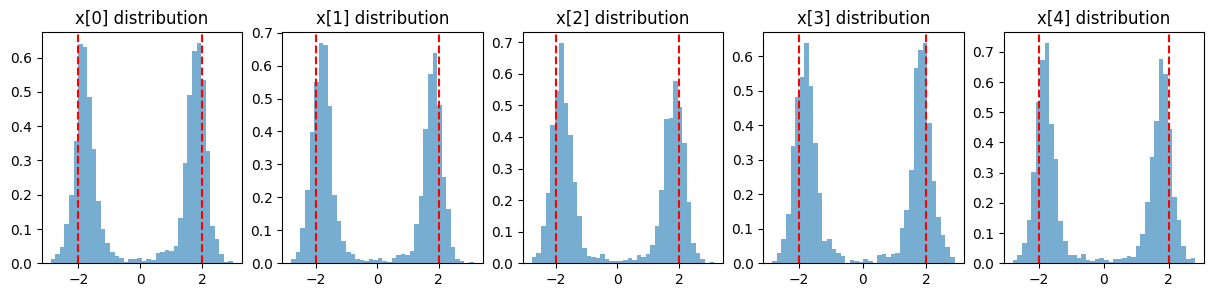

In [ ]:
# =========================================================
# PPO-RLFS for Many-Well (MW54) with Adaptive Annealing — Fixed
# =========================================================
import jax
import jax.numpy as jnp
from jax import random, vmap, lax, jit
import optax
from flax import linen as nn
from flax.training.train_state import TrainState
import numpy as np

# =========================================================
# 1. Target: Independent Double-Well Potential
# =========================================================
D = 5
DELTA = 4.0

def energy_doublewell(x, delta=DELTA):
    return jnp.sum((x**2 - delta)**2, axis=-1)

def log_unnormalized_pi(x):
    def single(xx): return -energy_doublewell(xx)
    return vmap(single)(x) if x.ndim == 2 else single(x)

def terminal_reward(x_T):
    return log_unnormalized_pi(x_T)

# =========================================================
# 2. RLFS transition
# =========================================================
SIGMA_INIT = 0.1
SIGMA_FINAL = 0.1
ENTROPY_COEF = 0.01
T_HORIZON = 32
FREEZE = 500

def env_step(key, x_t, t_frac, mu_t, sigma, sigma_ref):
    """Stable forward/backward KL reward step."""
    B, dim = x_t.shape
    key_a, _ = random.split(key)
    eps = random.normal(key_a, (B, dim))
    a_t = mu_t + sigma * eps
    x_next = x_t + a_t        # <== smaller integration step for stability

    mean_f = x_t + mu_t
    diff_f = x_next - mean_f
    sigref2 = sigma**2
    logF = -0.5 * jnp.sum((diff_f**2) / sigref2, axis=1)

    coef = jnp.sqrt(1.0 - sigma**2)
    mean_b = coef * x_next
    diff_b = x_t - mean_b
    logB = -0.5 * jnp.sum((diff_b**2) / sigref2, axis=1)

    r_t = logB - logF
    diff_a = (a_t - mu_t) / sigma
    logp = -0.5 * jnp.sum(diff_a**2, axis=1)
    return x_next, a_t, logp, r_t

# =========================================================
# Actor / Critic Networks (bounded)
# =========================================================
class Actor(nn.Module):
    D: int
    hidden: int = 256
    @nn.compact
    def __call__(self, x, t):
        h = jnp.concatenate([x, t], axis=-1)
        h = nn.tanh(nn.Dense(self.hidden,
                             kernel_init=nn.initializers.normal(1e-1),
                             bias_init=nn.initializers.zeros)(h))
        h = nn.tanh(nn.Dense(self.hidden,
                             kernel_init=nn.initializers.normal(1e-1),
                             bias_init=nn.initializers.zeros)(h))
        out = nn.Dense(self.D,
                       kernel_init=nn.initializers.normal(1e-3),
                       bias_init=nn.initializers.zeros)(h)
        return out

class Critic(nn.Module):
    hidden: int = 256
    @nn.compact
    def __call__(self, x, t_frac):
        h = jnp.concatenate([x, t_frac], axis=-1)
        h = nn.tanh(nn.Dense(self.hidden)(h))
        h = nn.tanh(nn.Dense(self.hidden)(h))
        v = nn.Dense(1)(h)
        return v.squeeze(-1)

class ActorState(TrainState): sigma: float
class CriticState(TrainState): pass

# =========================================================
# 3. MMD metric (robust)
# =========================================================
def pairwise_sq_dists(X, Y):
    X_norm = jnp.sum(X**2, axis=1, keepdims=True)
    Y_norm = jnp.sum(Y**2, axis=1, keepdims=True).T
    return X_norm + Y_norm - 2.0 * (X @ Y.T)

def rbf_kernel_matrix(X, Y, gamma):
    d2 = pairwise_sq_dists(X, Y)
    return jnp.exp(-gamma * d2)

def median_kernel_width(X, Y):
    Z = jnp.concatenate([X, Y], axis=0)
    d2 = pairwise_sq_dists(Z, Z)
    d2_flat = d2[jnp.triu_indices(d2.shape[0], k=1)]
    d2_flat = d2_flat[jnp.isfinite(d2_flat)]
    if d2_flat.size == 0:
        return 1.0
    med = jnp.median(jnp.sqrt(jnp.clip(d2_flat, 1e-6, 1e6)))
    med = jnp.maximum(med, 1e-3)
    sigma2 = med**2
    return 1.0 / (2.0 * sigma2)

def mmd_unbiased_rbf(X, Y):
    X = X[jnp.isfinite(X).all(axis=1)]
    Y = Y[jnp.isfinite(Y).all(axis=1)]
    n, m = X.shape[0], Y.shape[0]
    if n < 2 or m < 2:
        return jnp.nan
    gamma = median_kernel_width(X, Y)
    Kxx = rbf_kernel_matrix(X, X, gamma)
    Kyy = rbf_kernel_matrix(Y, Y, gamma)
    Kxy = rbf_kernel_matrix(X, Y, gamma)
    sum_Kxx = (jnp.sum(Kxx) - jnp.trace(Kxx)) / (n * (n - 1) + 1e-12)
    sum_Kyy = (jnp.sum(Kyy) - jnp.trace(Kyy)) / (m * (m - 1) + 1e-12)
    sum_Kxy = jnp.sum(Kxy) / (n * m + 1e-12)
    val = sum_Kxx + sum_Kyy - 2.0 * sum_Kxy
    return jnp.nan_to_num(val, nan=0.0, posinf=0.0, neginf=0.0)

def mode_sign_pattern(x):
    bits = (x >= 0).astype(jnp.int32)
    powers = (2 ** jnp.arange(x.shape[1], dtype=jnp.int32))
    codes = jnp.sum(bits * powers[None, :], axis=1)
    return codes

def mode_coverage_stats(x, D):
    codes = mode_sign_pattern(x)
    unique_codes, counts = jnp.unique(codes, return_counts=True)
    n_modes_hit = unique_codes.shape[0]
    full_K = 2 ** D
    hist = jnp.zeros((full_K,), dtype=jnp.int32).at[unique_codes].set(counts)
    freq = hist / jnp.sum(hist)
    return n_modes_hit, freq

# =========================================================
# 4. Rollout + GAE
# =========================================================
def rollout_episode(rng, actor_params, critic_params,
                    actor_apply, critic_apply,
                    BATCH, D, T, sigma, sigma_ref):
    rng, key_init = random.split(rng)
    x0 = random.normal(key_init, (BATCH, D))

    def body(carry, t_idx):
        rng, x_t = carry
        t_frac = jnp.ones((BATCH, 1)) * (t_idx / T)
        mu_t = actor_apply(actor_params, x_t, t_frac)
        rng, step_key = random.split(rng)
        x_next, a_t, logp, r_t = env_step(step_key, x_t, t_frac, mu_t, sigma, sigma_ref)
        v_t = critic_apply(critic_params, x_t, t_frac)
        return (rng, x_next), {
            "x_t": x_t, "a_t": a_t, "logprob": logp,
            "value": v_t, "t_frac": t_frac.squeeze(-1),
            "rewards": r_t
        }

    (rng, x_T), traj = lax.scan(body, (rng, x0), jnp.arange(T))

    # Compute terminal reward and make final step terminal (no bootstrapping)
    rew_T = terminal_reward(x_T)
    rewards = jnp.stack(traj["rewards"], axis=0)
    rewards = rewards.at[-1].add(rew_T)

    v_T = jnp.zeros((BATCH,))  # <-- FIXED: true terminal, no future bootstrap

    traj["rewards"] = rewards
    traj["v_T"] = v_T
    traj["x_T"] = x_T
    traj["terminal_bonus"] = rew_T
    return rng, traj


def compute_gae(traj, gamma=1.0, lam=0.95):
    rewards, values, v_T = traj["rewards"], traj["value"], traj["v_T"]
    T_len, B = rewards.shape
    def backward(carry, t_idx):
        gae, next_value = carry
        r_t, v_t = rewards[t_idx], values[t_idx]
        delta = r_t + gamma * next_value - v_t
        gae_t = delta + gamma * lam * gae
        return (gae_t, v_t), gae_t
    (_, _), adv_rev = lax.scan(backward, (jnp.zeros((B,)), v_T), jnp.arange(T_len-1, -1, -1))
    advantages = jnp.flip(adv_rev, axis=0)
    returns = advantages + values
    return advantages, returns

# =========================================================
# 5. PPO loss
# =========================================================
def gaussian_logprob(mu, sigma, a):
    diff = (a - mu) / sigma
    return -0.5 * jnp.sum(diff**2, axis=-1)

def ppo_loss(actor_params, critic_params, batch, actor_apply, critic_apply,
             sigma, clip_eps=0.2, vf_coef=0.5, entropy_coef=ENTROPY_COEF):
    x_t, t_frac, a_t, old_lp, adv_t, ret_t = (
        batch["x_t"], batch["t_frac"], batch["a_t"],
        batch["logprob"], batch["adv"], batch["ret"]
    )
    mu = actor_apply(actor_params, x_t, t_frac[:,None])
    new_lp = gaussian_logprob(mu, sigma, a_t)
    ratio = jnp.exp(new_lp - old_lp)
    adv_norm = (adv_t - jnp.mean(adv_t)) / (jnp.std(adv_t) + 1e-8)
    surr1 = ratio * adv_norm
    surr2 = jnp.clip(ratio, 1.0-clip_eps, 1.0+clip_eps) * adv_norm
    actor_obj = -jnp.mean(jnp.minimum(surr1, surr2))
    v_pred = critic_apply(critic_params, x_t, t_frac[:,None])
    v_loss = jnp.mean((ret_t - v_pred)**2)
    dim = a_t.shape[-1]
    entropy = 0.5 * jnp.mean(dim * (1.0 + jnp.log(2*jnp.pi*(sigma**2))))
    total_loss = actor_obj + vf_coef*v_loss - entropy_coef*entropy
    aux = {"actor_loss": actor_obj, "critic_loss": v_loss,
           "ratio_mean": jnp.mean(ratio), "entropy": entropy}
    return total_loss, aux

# =========================================================
# 6. Annealing Schedules
# =========================================================
def sigma_schedule(it, sigma_init=SIGMA_INIT, sigma_final=SIGMA_FINAL, freeze_iter=FREEZE):
    frac = jnp.clip(it / freeze_iter, 0.0, 1.0)
    return sigma_init + frac * (sigma_final - sigma_init)

def entropy_coef_schedule(it, warmup_iter=500, base_coef=0.05, boosted_coef=0.01):
    return jnp.where(it < warmup_iter, base_coef, boosted_coef)

import matplotlib.pyplot as plt
import jax.numpy as jnp

def plot_dim_histograms(x_T, delta=4.0):
    D = x_T.shape[1]
    fig, axes = plt.subplots(1, D, figsize=(3*D, 3))
    for d in range(D):
        axes[d].hist(x_T[:, d], bins=40, density=True, alpha=0.6)
        axes[d].axvline(jnp.sqrt(delta), color='red', linestyle='--')
        axes[d].axvline(-jnp.sqrt(delta), color='red', linestyle='--')
        axes[d].set_title(f"x[{d}] distribution")
    plt.show()



# =========================================================
# 7. Training
# =========================================================
def train_manywell_ppo(rng_key=random.PRNGKey(0), D=5, BATCH=1024, T=T_HORIZON,
                       actor_lr=1e-5, critic_lr=1e-5, ppo_epochs=3,
                       clip_eps=0.2, NITER=1000, MINIBATCH=20000):
    actor, critic = Actor(D=D, hidden=256), Critic(hidden=256)
    rng_key, key_actor, key_critic = random.split(rng_key, 3)
    dummy_x, dummy_t = random.normal(key_actor, (1,D)), jnp.zeros((1,1))
    actor_params, critic_params = actor.init(key_actor, dummy_x, dummy_t), critic.init(key_critic, dummy_x, dummy_t)
    # gradient clipping
    actor_opt  = optax.chain(optax.clip_by_global_norm(1.0), optax.adam(actor_lr))
    critic_opt = optax.chain(optax.clip_by_global_norm(1.0), optax.adam(critic_lr))
    actor_state = ActorState.create(apply_fn=actor.apply, params=actor_params, tx=actor_opt, sigma=SIGMA_INIT)
    critic_state = CriticState.create(apply_fn=critic.apply, params=critic_params, tx=critic_opt)
    ref_samples_5d = 2.0 * (2 * (random.randint(rng_key, (2000, D), 0, 2) - 0.5))

    @jit
    def do_rollout(rng_key, actor_params, critic_params, sigma, sigma_ref):
        rng_key, traj = rollout_episode(rng_key, actor_params, critic_params,
                                        actor.apply, critic.apply,
                                        BATCH, D, T, sigma, sigma_ref)
        adv, ret = compute_gae(traj)
        batch = {
            "x_t": traj["x_t"].reshape(T * BATCH, D),
            "a_t": traj["a_t"].reshape(T * BATCH, D),
            "t_frac": traj["t_frac"].reshape(T * BATCH),
            "logprob": traj["logprob"].reshape(T * BATCH),
            "adv": adv.reshape(T * BATCH),
            "ret": ret.reshape(T * BATCH),
        }
        mean_logpiT = jnp.mean(traj["terminal_bonus"])
        logpi_T = traj["terminal_bonus"]
        return rng_key, batch, mean_logpiT, traj["x_T"], logpi_T

    @jit
    def ppo_update(actor_state, critic_state, batch, sigma, ent_coef):
        def loss_fn_actor(params):
            loss_val, aux = ppo_loss(params, critic_state.params, batch,
                                     actor_state.apply_fn, critic_state.apply_fn,
                                     sigma=sigma, clip_eps=clip_eps, entropy_coef=ent_coef)
            return loss_val, aux
        def critic_only_loss(params):
            _, aux = ppo_loss(actor_state.params, params, batch,
                              actor_state.apply_fn, critic_state.apply_fn,
                              sigma=sigma, clip_eps=clip_eps, entropy_coef=ent_coef)
            return aux["critic_loss"], aux
        actor_grads, actor_aux = jax.grad(loss_fn_actor, has_aux=True)(actor_state.params)
        critic_grads, critic_aux = jax.grad(critic_only_loss, has_aux=True)(critic_state.params)
        new_actor_state = actor_state.apply_gradients(grads=actor_grads)
        new_critic_state = critic_state.apply_gradients(grads=critic_grads)
        aux = {"actor_loss": actor_aux["actor_loss"],
               "critic_loss": critic_aux["critic_loss"],
               "ratio_mean": actor_aux["ratio_mean"],
               "entropy": actor_aux["entropy"]}
        return new_actor_state, new_critic_state, aux

    for it in range(1, NITER+1):
        sigma_now = float(sigma_schedule(it))
        ent_coef  = float(entropy_coef_schedule(it))
        rng_key, batch, mean_logpiT, x_T, logpi_T = do_rollout(
            rng_key, actor_state.params, critic_state.params, sigma_now, sigma_now
        )

        N_total = batch["x_t"].shape[0]
        idx = jnp.arange(N_total)
        for _ in range(ppo_epochs):
            rng_key, subkey = random.split(rng_key)
            perm = random.permutation(subkey, idx)
            for start in range(0, N_total, MINIBATCH):
                mb_idx = perm[start:start+MINIBATCH]
                minibatch = {k: v[mb_idx] for k, v in batch.items()}
                actor_state, critic_state, aux = ppo_update(actor_state.replace(sigma=sigma_now),
                                                            critic_state, minibatch,
                                                            sigma_now, ent_coef)
        if it % 100 == 0 or it <= 5:
            q1, q2, q3 = jnp.percentile(logpi_T, jnp.array([25,50,75]))
            iqr = q3 - q1
            print(f"[Iter {it:04d}] σ={sigma_now:.3f} log ν(x_T) quartiles=({q1:.1f},{q2:.1f},{q3:.1f}) "
                  f"IQR={iqr:.1f} | actor_loss={aux['actor_loss']:.3f} "
                  f"critic_loss={aux['critic_loss']:.3f} ratio={aux['ratio_mean']:.3f} H={aux['entropy']:.3f}")
            model_eval, ref_eval = x_T[:1000], ref_samples_5d[:1000]
            mmd2_val = float(mmd_unbiased_rbf(model_eval, ref_eval))
            n_modes, freq = mode_coverage_stats(x_T, D)
            top, bottom = jnp.sort(freq)[-1], jnp.sort(freq)[0]
            print(f"   ↳ modes_hit={int(n_modes)}/{2**D} | top mode mass={float(top):.3f} | bottom mode mass={float(bottom):.3f}")
            print(f"   ↳ MMD²={mmd2_val:.4e}")

            # Example usage in training loop (when you print stats):
            plot_dim_histograms(x_T, delta=DELTA)

    return actor_state, critic_state

# =========================================================
# MAIN
# =========================================================
if __name__ == "__main__":
    actor_state, critic_state = train_manywell_ppo(
        rng_key=random.PRNGKey(0),
        D=D,
        BATCH=2048,
        T=50,
        actor_lr=5e-5,
        critic_lr=5e-5,
        ppo_epochs=4,
        clip_eps=0.2,
        NITER=1000,
        MINIBATCH=5000
    )

In [ ]:
import jax
import jax.numpy as jnp
from jax import lax, random
from jax.scipy.special import logsumexp

# =========================================================
# Pairwise squared distances
# =========================================================
def pairwise_sq_dists(X, Y):
    X2 = jnp.sum(X**2, axis=1, keepdims=True)
    Y2 = jnp.sum(Y**2, axis=1, keepdims=True).T
    return X2 + Y2 - 2.0 * (X @ Y.T)

# =========================================================
# Stable Sinkhorn divergence (Genevay et al., 2019)
# =========================================================
def _sinkhorn_cost_logdomain(C, a, b, eps, n_iters):
    """Compute entropic OT cost W_eps(a,b) in a stable log-domain form."""
    log_a = jnp.log(a)
    log_b = jnp.log(b)
    f = jnp.zeros_like(a)
    g = jnp.zeros_like(b)

    def body_fn(_, state):
        f, g = state
        term_f = (g[None, :] - C) / eps + log_b[None, :]
        f = eps * (log_a - logsumexp(term_f, axis=1))
        term_g = (f[:, None] - C) / eps + log_a[:, None]
        g = eps * (log_b - logsumexp(term_g, axis=0))
        return (f, g)

    f, g = lax.fori_loop(0, n_iters, body_fn, (f, g))
    return jnp.sum(a * f) + jnp.sum(b * g)

def sinkhorn_divergence(X, Y, eps=1e-2, n_iters=100):
    """Compute stabilized Sinkhorn divergence S_eps(X,Y)."""
    X = X[jnp.isfinite(X).all(axis=1)]
    Y = Y[jnp.isfinite(Y).all(axis=1)]

    N, M = X.shape[0], Y.shape[0]
    a = jnp.full((N,), 1.0 / N)
    b = jnp.full((M,), 1.0 / M)

    C_xy = pairwise_sq_dists(X, Y)
    C_xx = pairwise_sq_dists(X, X)
    C_yy = pairwise_sq_dists(Y, Y)

    W_xy = _sinkhorn_cost_logdomain(C_xy, a, b, eps, n_iters)
    W_xx = _sinkhorn_cost_logdomain(C_xx, a, a, eps, n_iters)
    W_yy = _sinkhorn_cost_logdomain(C_yy, b, b, eps, n_iters)

    return W_xy - 0.5 * (W_xx + W_yy)

# =========================================================
# Sampling from trained PPO-RLFS actor
# =========================================================
def generate_samples(rng_key, actor_state, D=5, T=50, N=2000):
    """Generate final samples x_T from trained actor."""
    actor_apply = actor_state.apply_fn
    params = actor_state.params
    sigma = actor_state.sigma

    rng_key, key_init = random.split(rng_key)
    x0 = random.normal(key_init, (N, D))

    def body(carry, t_idx):
        rng, x_t = carry
        t_frac = jnp.ones((N, 1)) * (t_idx / T)
        mu_t = actor_apply(params, x_t, t_frac)
        rng, step_key = random.split(rng)
        eps = random.normal(step_key, (N, D))
        a_t = mu_t + sigma * eps
        x_next = x_t + a_t
        return (rng, x_next), x_next

    (_, x_T_seq) = lax.scan(body, (rng_key, x0), jnp.arange(T))
    x_T = x_T_seq[-1]
    return x_T

# =========================================================
# Standardization for evaluation
# =========================================================
def standardize_for_eval(X, Y):
    """Use reference statistics to standardize both samples."""
    mean = jnp.mean(Y, axis=0, keepdims=True)
    std = jnp.std(Y, axis=0, keepdims=True) + 1e-8
    return (X - mean) / std, (Y - mean) / std

# =========================================================
# Evaluation
# =========================================================
rng = random.PRNGKey(0)
rng, key = random.split(rng)
test_samples_5d = jnp.array(generate_samples(rng, actor_state, D=5, T=50, N=2000))
X_eval, Y_eval = standardize_for_eval(test_samples_5d, ref_samples_5d)
sd = sinkhorn_divergence(X_eval, Y_eval, eps=1e-3, n_iters=100)
mmd = mmd_unbiased_rbf(X_eval, Y_eval)
print("MMD²:", mmd)
print("Sinkhorn divergence:", sd)


MMD²: 0.002014637
Sinkhorn divergence: 0.13712397


In [3]:
# =========================================================
# PPO-RLFS for Many-Well (MW54) with Adaptive Annealing — Fixed
# =========================================================
import jax
import jax.numpy as jnp
from jax import random, vmap, lax, jit
import optax
from flax import linen as nn
from flax.training.train_state import TrainState
import numpy as np

# =========================================================
# 1. Target: Independent Double-Well Potential
# =========================================================
D = 5
DELTA = 4.0

def energy_doublewell(x, delta=DELTA):
    return jnp.sum((x**2 - delta)**2, axis=-1)

def log_unnormalized_pi(x):
    def single(xx): return -energy_doublewell(xx)
    return vmap(single)(x) if x.ndim == 2 else single(x)

def terminal_reward(x_T):
    return log_unnormalized_pi(x_T)

# =========================================================
# 2. RLFS transition
# =========================================================
SIGMA_INIT = 0.1
SIGMA_FINAL = 0.1
ENTROPY_COEF = 0.01
T_HORIZON = 32
FREEZE = 500

def env_step(key, x_t, t_frac, mu_t, sigma, sigma_ref):
    """Stable forward/backward KL reward step."""
    B, dim = x_t.shape
    key_a, _ = random.split(key)
    eps = random.normal(key_a, (B, dim))
    a_t = mu_t + sigma * eps
    x_next = x_t + a_t        # <== smaller integration step for stability

    mean_f = x_t + mu_t
    diff_f = x_next - mean_f
    sigref2 = sigma**2
    logF = -0.5 * jnp.sum((diff_f**2) / sigref2, axis=1)

    coef = jnp.sqrt(1.0 - sigma**2)
    mean_b = coef * x_next
    diff_b = x_t - mean_b
    logB = -0.5 * jnp.sum((diff_b**2) / sigref2, axis=1)

    r_t = logB - logF
    diff_a = (a_t - mu_t) / sigma
    logp = -0.5 * jnp.sum(diff_a**2, axis=1)
    return x_next, a_t, logp, r_t

# =========================================================
# Actor / Critic Networks (bounded)
# =========================================================
class Actor(nn.Module):
    D: int
    hidden: int = 256
    @nn.compact
    def __call__(self, x, t):
        h = jnp.concatenate([x, t], axis=-1)
        h = nn.tanh(nn.Dense(self.hidden,
                             kernel_init=nn.initializers.normal(1e-1),
                             bias_init=nn.initializers.zeros)(h))
        h = nn.tanh(nn.Dense(self.hidden,
                             kernel_init=nn.initializers.normal(1e-1),
                             bias_init=nn.initializers.zeros)(h))
        out = nn.Dense(self.D,
                       kernel_init=nn.initializers.normal(1e-3),
                       bias_init=nn.initializers.zeros)(h)
        return out

class Critic(nn.Module):
    hidden: int = 256
    @nn.compact
    def __call__(self, x, t_frac):
        h = jnp.concatenate([x, t_frac], axis=-1)
        h = nn.tanh(nn.Dense(self.hidden)(h))
        h = nn.tanh(nn.Dense(self.hidden)(h))
        v = nn.Dense(1)(h)
        return v.squeeze(-1)

class ActorState(TrainState): sigma: float
class CriticState(TrainState): pass

# =========================================================
# 3. MMD metric (robust)
# =========================================================
def pairwise_sq_dists(X, Y):
    X_norm = jnp.sum(X**2, axis=1, keepdims=True)
    Y_norm = jnp.sum(Y**2, axis=1, keepdims=True).T
    return X_norm + Y_norm - 2.0 * (X @ Y.T)

def rbf_kernel_matrix(X, Y, gamma):
    d2 = pairwise_sq_dists(X, Y)
    return jnp.exp(-gamma * d2)

def median_kernel_width(X, Y):
    Z = jnp.concatenate([X, Y], axis=0)
    d2 = pairwise_sq_dists(Z, Z)
    d2_flat = d2[jnp.triu_indices(d2.shape[0], k=1)]
    d2_flat = d2_flat[jnp.isfinite(d2_flat)]
    if d2_flat.size == 0:
        return 1.0
    med = jnp.median(jnp.sqrt(jnp.clip(d2_flat, 1e-6, 1e6)))
    med = jnp.maximum(med, 1e-3)
    sigma2 = med**2
    return 1.0 / (2.0 * sigma2)

def mmd_unbiased_rbf(X, Y):
    X = X[jnp.isfinite(X).all(axis=1)]
    Y = Y[jnp.isfinite(Y).all(axis=1)]
    n, m = X.shape[0], Y.shape[0]
    if n < 2 or m < 2:
        return jnp.nan
    gamma = median_kernel_width(X, Y)
    Kxx = rbf_kernel_matrix(X, X, gamma)
    Kyy = rbf_kernel_matrix(Y, Y, gamma)
    Kxy = rbf_kernel_matrix(X, Y, gamma)
    sum_Kxx = (jnp.sum(Kxx) - jnp.trace(Kxx)) / (n * (n - 1) + 1e-12)
    sum_Kyy = (jnp.sum(Kyy) - jnp.trace(Kyy)) / (m * (m - 1) + 1e-12)
    sum_Kxy = jnp.sum(Kxy) / (n * m + 1e-12)
    val = sum_Kxx + sum_Kyy - 2.0 * sum_Kxy
    return jnp.nan_to_num(val, nan=0.0, posinf=0.0, neginf=0.0)

def mode_sign_pattern(x):
    bits = (x >= 0).astype(jnp.int32)
    powers = (2 ** jnp.arange(x.shape[1], dtype=jnp.int32))
    codes = jnp.sum(bits * powers[None, :], axis=1)
    return codes

def mode_coverage_stats(x, D):
    codes = mode_sign_pattern(x)
    unique_codes, counts = jnp.unique(codes, return_counts=True)
    n_modes_hit = unique_codes.shape[0]
    full_K = 2 ** D
    hist = jnp.zeros((full_K,), dtype=jnp.int32).at[unique_codes].set(counts)
    freq = hist / jnp.sum(hist)
    return n_modes_hit, freq

# =========================================================
# 4. Rollout + GAE
# =========================================================
def rollout_episode(rng, actor_params, critic_params,
                    actor_apply, critic_apply,
                    BATCH, D, T, sigma, sigma_ref):
    rng, key_init = random.split(rng)
    x0 = random.normal(key_init, (BATCH, D))

    def body(carry, t_idx):
        rng, x_t = carry
        t_frac = jnp.ones((BATCH, 1)) * (t_idx / T)
        mu_t = actor_apply(actor_params, x_t, t_frac)
        rng, step_key = random.split(rng)
        x_next, a_t, logp, r_t = env_step(step_key, x_t, t_frac, mu_t, sigma, sigma_ref)
        v_t = critic_apply(critic_params, x_t, t_frac)
        return (rng, x_next), {
            "x_t": x_t, "a_t": a_t, "logprob": logp,
            "value": v_t, "t_frac": t_frac.squeeze(-1),
            "rewards": r_t
        }

    (rng, x_T), traj = lax.scan(body, (rng, x0), jnp.arange(T))

    # Compute terminal reward and make final step terminal (no bootstrapping)
    rew_T = terminal_reward(x_T)
    rewards = jnp.stack(traj["rewards"], axis=0)
    rewards = rewards.at[-1].add(rew_T)

    v_T = jnp.zeros((BATCH,))  # <-- FIXED: true terminal, no future bootstrap

    traj["rewards"] = rewards
    traj["v_T"] = v_T
    traj["x_T"] = x_T
    traj["terminal_bonus"] = rew_T
    return rng, traj


def compute_gae(traj, gamma=1.0, lam=0.95):
    rewards, values, v_T = traj["rewards"], traj["value"], traj["v_T"]
    T_len, B = rewards.shape
    def backward(carry, t_idx):
        gae, next_value = carry
        r_t, v_t = rewards[t_idx], values[t_idx]
        delta = r_t + gamma * next_value - v_t
        gae_t = delta + gamma * lam * gae
        return (gae_t, v_t), gae_t
    (_, _), adv_rev = lax.scan(backward, (jnp.zeros((B,)), v_T), jnp.arange(T_len-1, -1, -1))
    advantages = jnp.flip(adv_rev, axis=0)
    returns = advantages + values
    return advantages, returns

# =========================================================
# 5. PPO loss
# =========================================================
def gaussian_logprob(mu, sigma, a):
    diff = (a - mu) / sigma
    return -0.5 * jnp.sum(diff**2, axis=-1)

def ppo_loss(actor_params, critic_params, batch, actor_apply, critic_apply,
             sigma, clip_eps=0.2, vf_coef=0.5, entropy_coef=ENTROPY_COEF):
    x_t, t_frac, a_t, old_lp, adv_t, ret_t = (
        batch["x_t"], batch["t_frac"], batch["a_t"],
        batch["logprob"], batch["adv"], batch["ret"]
    )
    mu = actor_apply(actor_params, x_t, t_frac[:,None])
    new_lp = gaussian_logprob(mu, sigma, a_t)
    ratio = jnp.exp(new_lp - old_lp)
    adv_norm = (adv_t - jnp.mean(adv_t)) / (jnp.std(adv_t) + 1e-8)
    surr1 = ratio * adv_norm
    surr2 = jnp.clip(ratio, 1.0-clip_eps, 1.0+clip_eps) * adv_norm
    actor_obj = -jnp.mean(jnp.minimum(surr1, surr2))
    v_pred = critic_apply(critic_params, x_t, t_frac[:,None])
    v_loss = jnp.mean((ret_t - v_pred)**2)
    dim = a_t.shape[-1]
    entropy = 0.5 * jnp.mean(dim * (1.0 + jnp.log(2*jnp.pi*(sigma**2))))
    total_loss = actor_obj + vf_coef*v_loss - entropy_coef*entropy
    aux = {"actor_loss": actor_obj, "critic_loss": v_loss,
           "ratio_mean": jnp.mean(ratio), "entropy": entropy}
    return total_loss, aux

# =========================================================
# 6. Annealing Schedules
# =========================================================
def sigma_schedule(it, sigma_init=SIGMA_INIT, sigma_final=SIGMA_FINAL, freeze_iter=FREEZE):
    frac = jnp.clip(it / freeze_iter, 0.0, 1.0)
    return sigma_init + frac * (sigma_final - sigma_init)

def entropy_coef_schedule(it, warmup_iter=500, base_coef=0.05, boosted_coef=0.01):
    return jnp.where(it < warmup_iter, base_coef, boosted_coef)

import matplotlib.pyplot as plt
import jax.numpy as jnp

def plot_dim_histograms(x_T, delta=4.0):
    D = x_T.shape[1]
    fig, axes = plt.subplots(1, D, figsize=(3*D, 3))
    for d in range(D):
        axes[d].hist(x_T[:, d], bins=40, density=True, alpha=0.6)
        axes[d].axvline(jnp.sqrt(delta), color='red', linestyle='--')
        axes[d].axvline(-jnp.sqrt(delta), color='red', linestyle='--')
        axes[d].set_title(f"x[{d}] distribution")
    plt.show()



# =========================================================
# 7. Training
# =========================================================
def train_manywell_ppo(rng_key=random.PRNGKey(0), D=5, BATCH=1024, T=T_HORIZON,
                       actor_lr=1e-5, critic_lr=1e-5, ppo_epochs=3,
                       clip_eps=0.2, NITER=1000, MINIBATCH=20000):
    actor, critic = Actor(D=D, hidden=256), Critic(hidden=256)
    rng_key, key_actor, key_critic = random.split(rng_key, 3)
    dummy_x, dummy_t = random.normal(key_actor, (1,D)), jnp.zeros((1,1))
    actor_params, critic_params = actor.init(key_actor, dummy_x, dummy_t), critic.init(key_critic, dummy_x, dummy_t)
    # gradient clipping
    actor_opt  = optax.chain(optax.clip_by_global_norm(1.0), optax.adam(actor_lr))
    critic_opt = optax.chain(optax.clip_by_global_norm(1.0), optax.adam(critic_lr))
    actor_state = ActorState.create(apply_fn=actor.apply, params=actor_params, tx=actor_opt, sigma=SIGMA_INIT)
    critic_state = CriticState.create(apply_fn=critic.apply, params=critic_params, tx=critic_opt)
    ref_samples_5d = 2.0 * (2 * (random.randint(rng_key, (2000, D), 0, 2) - 0.5))

    @jit
    def do_rollout(rng_key, actor_params, critic_params, sigma, sigma_ref):
        rng_key, traj = rollout_episode(rng_key, actor_params, critic_params,
                                        actor.apply, critic.apply,
                                        BATCH, D, T, sigma, sigma_ref)
        adv, ret = compute_gae(traj)
        batch = {
            "x_t": traj["x_t"].reshape(T * BATCH, D),
            "a_t": traj["a_t"].reshape(T * BATCH, D),
            "t_frac": traj["t_frac"].reshape(T * BATCH),
            "logprob": traj["logprob"].reshape(T * BATCH),
            "adv": adv.reshape(T * BATCH),
            "ret": ret.reshape(T * BATCH),
        }
        mean_logpiT = jnp.mean(traj["terminal_bonus"])
        logpi_T = traj["terminal_bonus"]
        return rng_key, batch, mean_logpiT, traj["x_T"], logpi_T

    @jit
    def ppo_update(actor_state, critic_state, batch, sigma, ent_coef):
        def loss_fn_actor(params):
            loss_val, aux = ppo_loss(params, critic_state.params, batch,
                                     actor_state.apply_fn, critic_state.apply_fn,
                                     sigma=sigma, clip_eps=clip_eps, entropy_coef=ent_coef)
            return loss_val, aux
        def critic_only_loss(params):
            _, aux = ppo_loss(actor_state.params, params, batch,
                              actor_state.apply_fn, critic_state.apply_fn,
                              sigma=sigma, clip_eps=clip_eps, entropy_coef=ent_coef)
            return aux["critic_loss"], aux
        actor_grads, actor_aux = jax.grad(loss_fn_actor, has_aux=True)(actor_state.params)
        critic_grads, critic_aux = jax.grad(critic_only_loss, has_aux=True)(critic_state.params)
        new_actor_state = actor_state.apply_gradients(grads=actor_grads)
        new_critic_state = critic_state.apply_gradients(grads=critic_grads)
        aux = {"actor_loss": actor_aux["actor_loss"],
               "critic_loss": critic_aux["critic_loss"],
               "ratio_mean": actor_aux["ratio_mean"],
               "entropy": actor_aux["entropy"]}
        return new_actor_state, new_critic_state, aux

    for it in range(1, NITER+1):
        sigma_now = float(sigma_schedule(it))
        ent_coef  = float(entropy_coef_schedule(it))
        rng_key, batch, mean_logpiT, x_T, logpi_T = do_rollout(
            rng_key, actor_state.params, critic_state.params, sigma_now, sigma_now
        )

        N_total = batch["x_t"].shape[0]
        idx = jnp.arange(N_total)
        for _ in range(ppo_epochs):
            rng_key, subkey = random.split(rng_key)
            perm = random.permutation(subkey, idx)
            for start in range(0, N_total, MINIBATCH):
                mb_idx = perm[start:start+MINIBATCH]
                minibatch = {k: v[mb_idx] for k, v in batch.items()}
                actor_state, critic_state, aux = ppo_update(actor_state.replace(sigma=sigma_now),
                                                            critic_state, minibatch,
                                                            sigma_now, ent_coef)
        if it % 100 == 0:
            q1, q2, q3 = jnp.percentile(logpi_T, jnp.array([25,50,75]))
            iqr = q3 - q1
            print(f"[Iter {it:04d}] σ={sigma_now:.3f} log ν(x_T) quartiles=({q1:.1f},{q2:.1f},{q3:.1f}) "
                  f"IQR={iqr:.1f} | actor_loss={aux['actor_loss']:.3f} "
                  f"critic_loss={aux['critic_loss']:.3f} ratio={aux['ratio_mean']:.3f} H={aux['entropy']:.3f}")
            model_eval, ref_eval = x_T[:1000], ref_samples_5d[:1000]
            mmd2_val = float(mmd_unbiased_rbf(model_eval, ref_eval))
            n_modes, freq = mode_coverage_stats(x_T, D)
            top, bottom = jnp.sort(freq)[-1], jnp.sort(freq)[0]
            print(f"   ↳ modes_hit={int(n_modes)}/{2**D} | top mode mass={float(top):.3f} | bottom mode mass={float(bottom):.3f}")
            print(f"   ↳ MMD²={mmd2_val:.4e}")

    return actor_state, critic_state

import jax
import jax.numpy as jnp
from jax import lax, random
from jax.scipy.special import logsumexp

# =========================================================
# Pairwise squared distances
# =========================================================
def pairwise_sq_dists(X, Y):
    X2 = jnp.sum(X**2, axis=1, keepdims=True)
    Y2 = jnp.sum(Y**2, axis=1, keepdims=True).T
    return X2 + Y2 - 2.0 * (X @ Y.T)

# =========================================================
# Stable Sinkhorn divergence (Genevay et al., 2019)
# =========================================================
def _sinkhorn_cost_logdomain(C, a, b, eps, n_iters):
    """Compute entropic OT cost W_eps(a,b) in a stable log-domain form."""
    log_a = jnp.log(a)
    log_b = jnp.log(b)
    f = jnp.zeros_like(a)
    g = jnp.zeros_like(b)

    def body_fn(_, state):
        f, g = state
        term_f = (g[None, :] - C) / eps + log_b[None, :]
        f = eps * (log_a - logsumexp(term_f, axis=1))
        term_g = (f[:, None] - C) / eps + log_a[:, None]
        g = eps * (log_b - logsumexp(term_g, axis=0))
        return (f, g)

    f, g = lax.fori_loop(0, n_iters, body_fn, (f, g))
    return jnp.sum(a * f) + jnp.sum(b * g)

def sinkhorn_divergence(X, Y, eps=1e-2, n_iters=100):
    """Compute stabilized Sinkhorn divergence S_eps(X,Y)."""
    X = X[jnp.isfinite(X).all(axis=1)]
    Y = Y[jnp.isfinite(Y).all(axis=1)]

    N, M = X.shape[0], Y.shape[0]
    a = jnp.full((N,), 1.0 / N)
    b = jnp.full((M,), 1.0 / M)

    C_xy = pairwise_sq_dists(X, Y)
    C_xx = pairwise_sq_dists(X, X)
    C_yy = pairwise_sq_dists(Y, Y)

    W_xy = _sinkhorn_cost_logdomain(C_xy, a, b, eps, n_iters)
    W_xx = _sinkhorn_cost_logdomain(C_xx, a, a, eps, n_iters)
    W_yy = _sinkhorn_cost_logdomain(C_yy, b, b, eps, n_iters)

    return W_xy - 0.5 * (W_xx + W_yy)

# =========================================================
# Sampling from trained PPO-RLFS actor
# =========================================================
def generate_samples(rng_key, actor_state, D=5, T=50, N=2000):
    """Generate final samples x_T from trained actor."""
    actor_apply = actor_state.apply_fn
    params = actor_state.params
    sigma = actor_state.sigma

    rng_key, key_init = random.split(rng_key)
    x0 = random.normal(key_init, (N, D))

    def body(carry, t_idx):
        rng, x_t = carry
        t_frac = jnp.ones((N, 1)) * (t_idx / T)
        mu_t = actor_apply(params, x_t, t_frac)
        rng, step_key = random.split(rng)
        eps = random.normal(step_key, (N, D))
        a_t = mu_t + sigma * eps
        x_next = x_t + a_t
        return (rng, x_next), x_next

    (_, x_T_seq) = lax.scan(body, (rng_key, x0), jnp.arange(T))
    x_T = x_T_seq[-1]
    return x_T

# =========================================================
# Standardization for evaluation
# =========================================================
def standardize_for_eval(X, Y):
    """Use reference statistics to standardize both samples."""
    mean = jnp.mean(Y, axis=0, keepdims=True)
    std = jnp.std(Y, axis=0, keepdims=True) + 1e-8
    return (X - mean) / std, (Y - mean) / std

# =========================================================
# Evaluation
# =========================================================
rng = random.PRNGKey(0)
rng, key = random.split(rng)
test_samples_5d = jnp.array(generate_samples(rng, actor_state, D=5, T=50, N=2000))
X_eval, Y_eval = standardize_for_eval(test_samples_5d, ref_samples_5d)
sd = sinkhorn_divergence(X_eval, Y_eval, eps=1e-3, n_iters=100)
mmd = mmd_unbiased_rbf(X_eval, Y_eval)


# =========================================================
# Multi-Seed Evaluation Loop (10 runs)
# =========================================================
SEEDS = list(range(10))
results = []

for seed in SEEDS:
    print(f"\n============================")
    print(f"   Running Seed = {seed}")
    print(f"============================\n")

    actor_state, critic_state = train_manywell_ppo(
        rng_key=random.PRNGKey(seed),
        D=5,
        BATCH=2048,
        T=50,
        actor_lr=5e-5,
        critic_lr=5e-5,
        ppo_epochs=4,
        clip_eps=0.2,
        NITER=500,
        MINIBATCH=5000
    )

    # Generate final samples
    rng = random.PRNGKey(seed + 999)
    model_samples = generate_samples(rng, actor_state, D=5, T=50, N=2000)

    # Standardize
    X_eval, Y_eval = standardize_for_eval(model_samples, ref_samples_5d)

    # Metrics
    mmd_val = float(mmd_unbiased_rbf(X_eval, Y_eval))
    sink_val = float(sinkhorn_divergence(X_eval, Y_eval, eps=1e-3, n_iters=100))

    # Mode coverage & imbalance
    n_modes, freq = mode_coverage_stats(model_samples, D=5)
    top_mass = float(jnp.max(freq))
    bottom_mass = float(jnp.min(freq))

    results.append((
    seed,
    n_modes,
    top_mass,
    bottom_mass,
    mmd_val,
    sink_val
))

results = np.array(results, dtype=[
    ("seed", int),
    ("modes_hit", int),
    ("top_mass", float),
    ("bottom_mass", float),
    ("mmd2", float),
    ("sinkhorn", float),
])

print("\n============================")
print("   FINAL SUMMARY (10 Seeds)")
print("============================\n")

def ms(x): return f"{np.mean(x):.4f} ± {np.std(x):.4f}"

print(f"Modes hit      : {ms(results['modes_hit'])}  / {2**5}")
print(f"Top mode mass  : {ms(results['top_mass'])}")
print(f"Bottom mass    : {ms(results['bottom_mass'])}")
print(f"MMD^2          : {ms(results['mmd2'])}")
print(f"Sinkhorn Dist. : {ms(results['sinkhorn'])}")



MMD²: 0.0022710562
Sinkhorn divergence: 0.14966993

   Running Seed = 0

[Iter 0100] σ=0.100 log ν(x_T) quartiles=(-20.9,-14.1,-8.6) IQR=12.3 | actor_loss=-0.000 critic_loss=15.369 ratio=0.998 H=-4.418
   ↳ modes_hit=32/32 | top mode mass=0.039 | bottom mode mass=0.021
   ↳ MMD²=3.1881e-03
[Iter 0200] σ=0.100 log ν(x_T) quartiles=(-18.4,-11.9,-7.0) IQR=11.4 | actor_loss=0.000 critic_loss=15.130 ratio=0.998 H=-4.418
   ↳ modes_hit=32/32 | top mode mass=0.042 | bottom mode mass=0.021
   ↳ MMD²=2.4260e-03
[Iter 0300] σ=0.100 log ν(x_T) quartiles=(-15.8,-10.1,-6.4) IQR=9.4 | actor_loss=-0.003 critic_loss=10.875 ratio=0.999 H=-4.418
   ↳ modes_hit=32/32 | top mode mass=0.042 | bottom mode mass=0.021
   ↳ MMD²=3.4943e-03
[Iter 0400] σ=0.100 log ν(x_T) quartiles=(-14.6,-9.4,-6.0) IQR=8.6 | actor_loss=-0.001 critic_loss=11.235 ratio=0.998 H=-4.418
   ↳ modes_hit=32/32 | top mode mass=0.050 | bottom mode mass=0.020
   ↳ MMD²=2.6519e-03
[Iter 0500] σ=0.100 log ν(x_T) quartiles=(-13.6,-8.7,-5.6) 

## Obtain histogram plot

[Iter 0001] σ=0.100 log ν(x_T) quartiles=(-61.0,-50.6,-40.9) IQR=20.1 | actor_loss=-0.001 critic_loss=892.707 ratio=1.001 H=-4.418
[Iter 0002] σ=0.100 log ν(x_T) quartiles=(-61.3,-51.2,-41.3) IQR=20.0 | actor_loss=-0.000 critic_loss=695.081 ratio=1.001 H=-4.418
[Iter 0003] σ=0.100 log ν(x_T) quartiles=(-60.4,-50.9,-41.1) IQR=19.3 | actor_loss=0.000 critic_loss=992.030 ratio=1.002 H=-4.418
[Iter 0004] σ=0.100 log ν(x_T) quartiles=(-59.4,-49.5,-40.8) IQR=18.6 | actor_loss=-0.003 critic_loss=516.653 ratio=1.000 H=-4.418
[Iter 0005] σ=0.100 log ν(x_T) quartiles=(-59.3,-49.8,-40.4) IQR=18.9 | actor_loss=-0.001 critic_loss=450.831 ratio=1.001 H=-4.418
[Iter 0100] σ=0.100 log ν(x_T) quartiles=(-20.9,-14.1,-8.6) IQR=12.3 | actor_loss=-0.000 critic_loss=15.369 ratio=0.998 H=-4.418
[Iter 0200] σ=0.100 log ν(x_T) quartiles=(-18.4,-11.9,-7.0) IQR=11.4 | actor_loss=0.000 critic_loss=15.130 ratio=0.998 H=-4.418
[Iter 0300] σ=0.100 log ν(x_T) quartiles=(-15.8,-10.1,-6.4) IQR=9.4 | actor_loss=-0.003 c

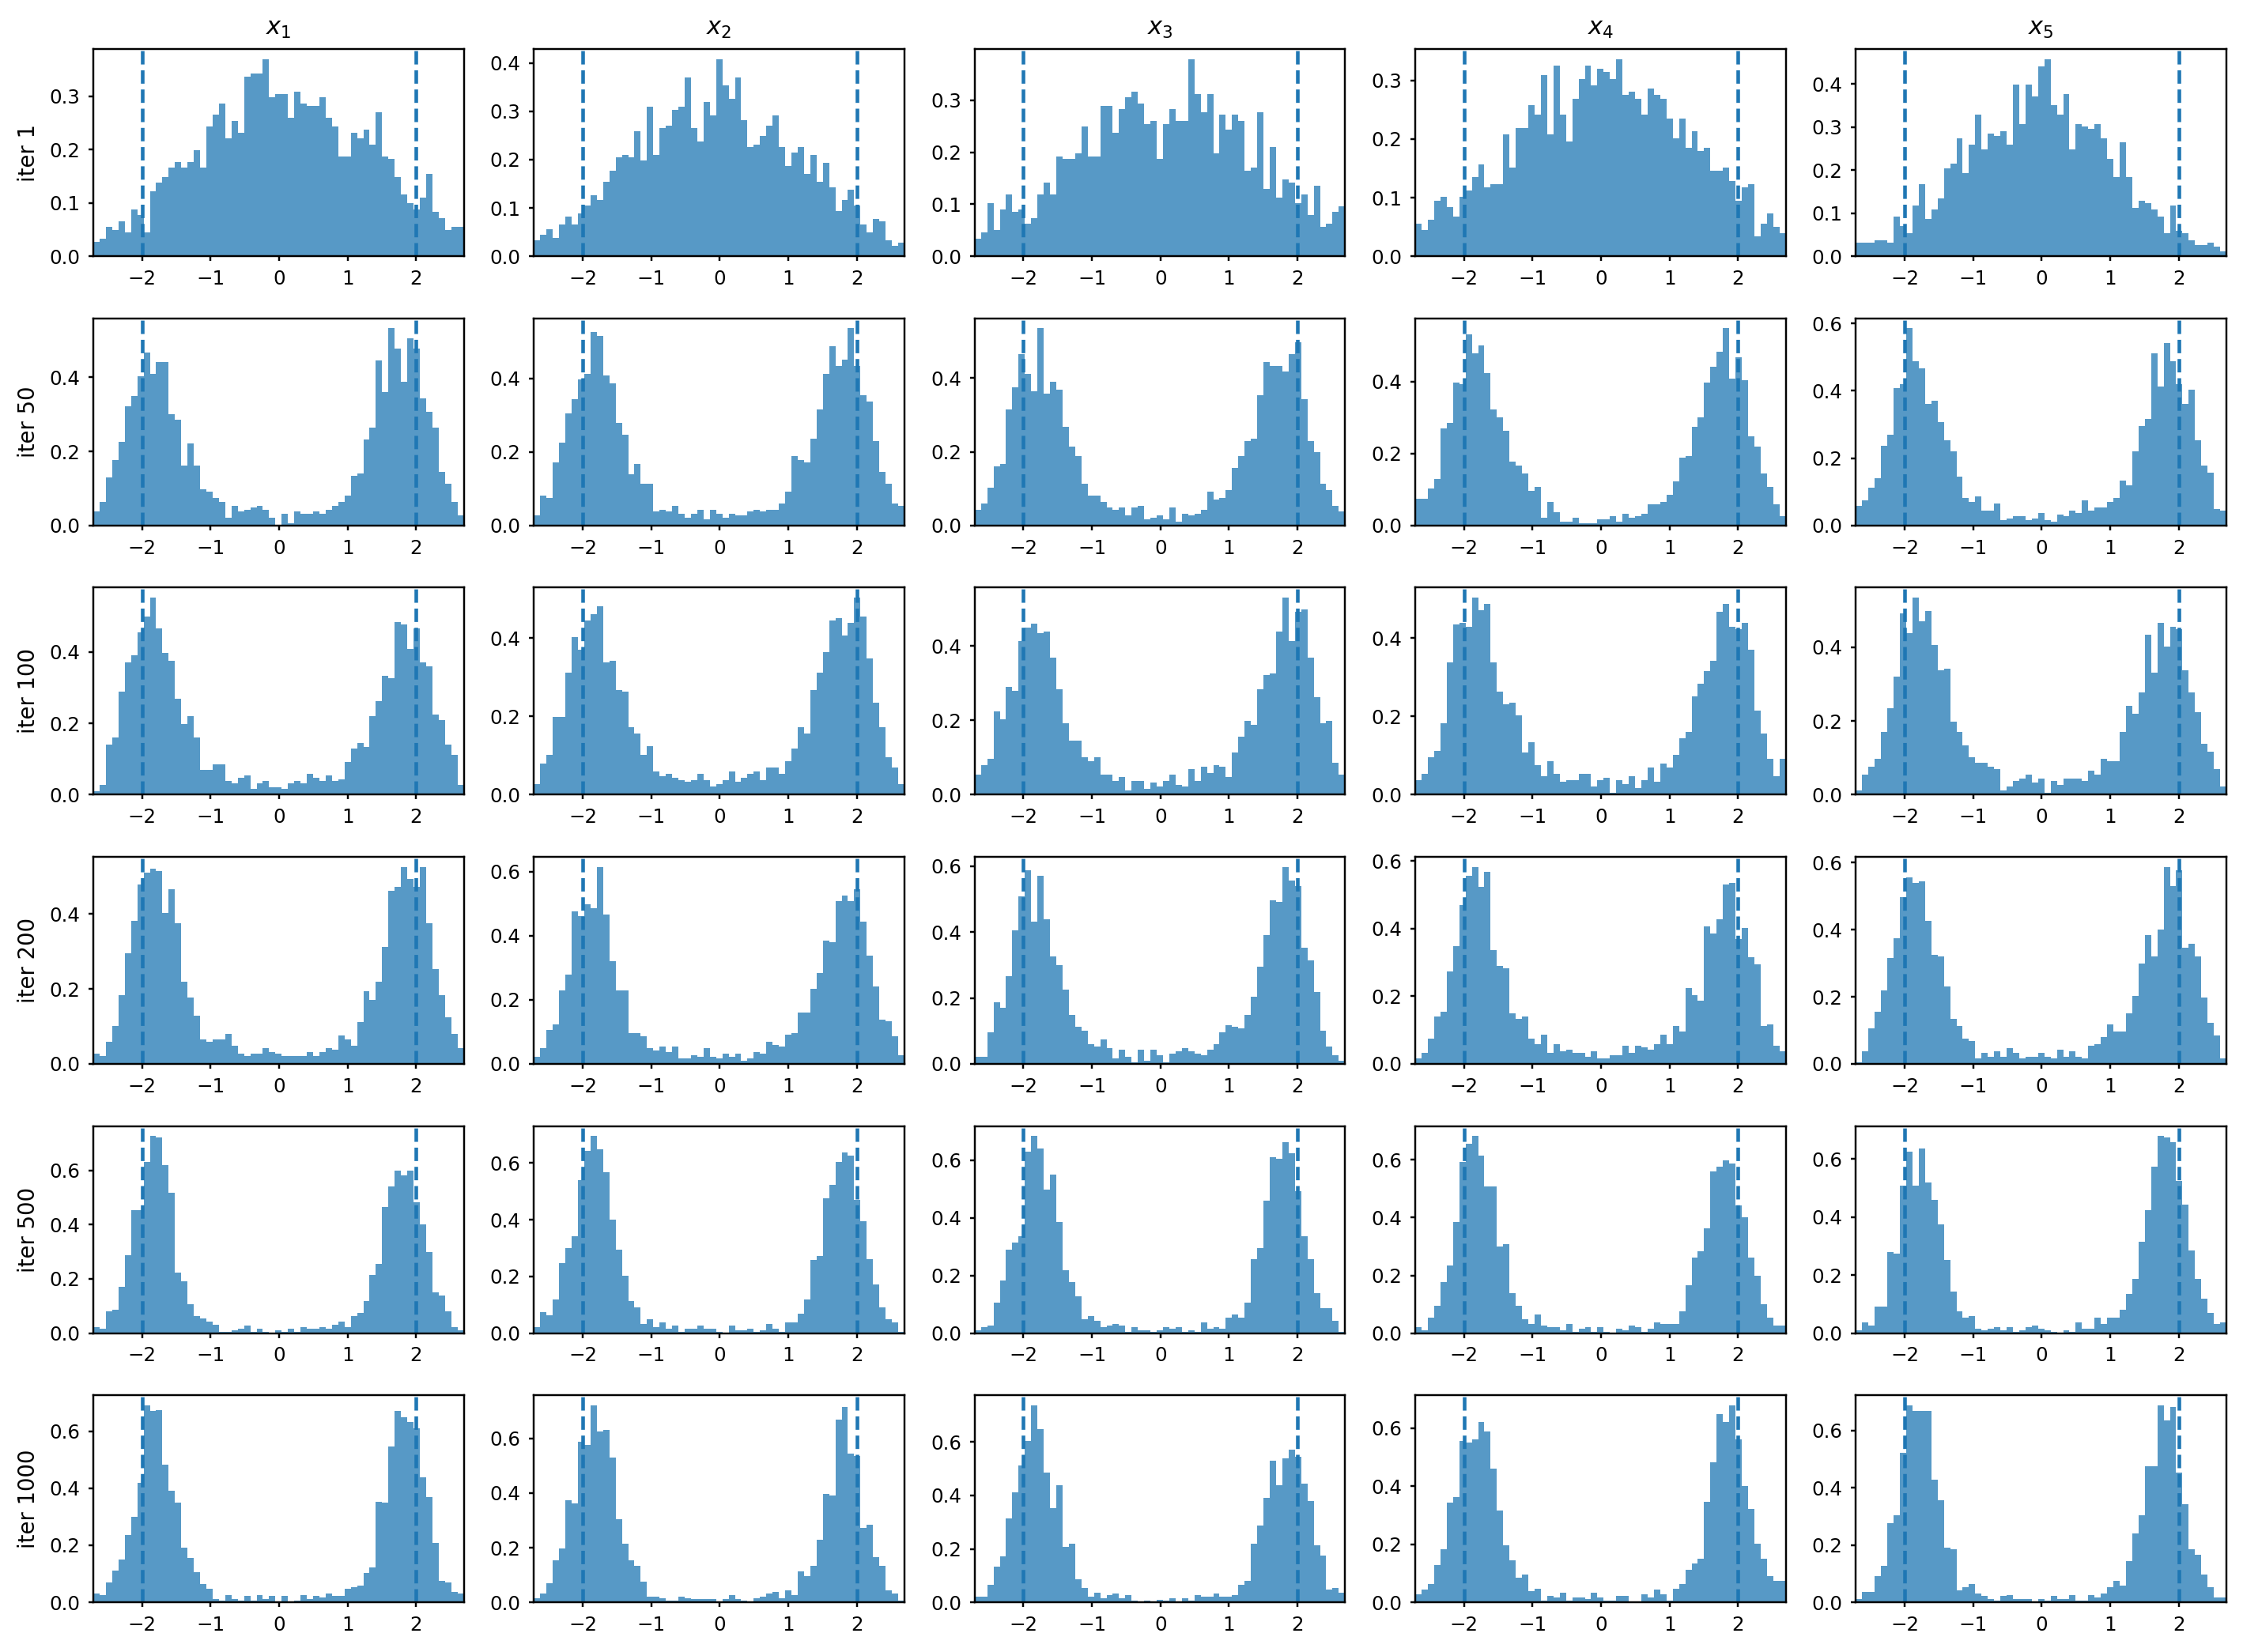

In [1]:
# =========================================================
# PPO-RLFS for Many-Well (MW54) with Adaptive Annealing — Fixed
# =========================================================
import jax
import jax.numpy as jnp
from jax import random, vmap, lax, jit
import optax
from flax import linen as nn
from flax.training.train_state import TrainState
import numpy as np

# =========================================================
# 1. Target: Independent Double-Well Potential
# =========================================================
D = 5
DELTA = 4.0

def energy_doublewell(x, delta=DELTA):
    return jnp.sum((x**2 - delta)**2, axis=-1)

def log_unnormalized_pi(x):
    def single(xx): return -energy_doublewell(xx)
    return vmap(single)(x) if x.ndim == 2 else single(x)

def terminal_reward(x_T):
    return log_unnormalized_pi(x_T)

# =========================================================
# 2. RLFS transition
# =========================================================
SIGMA_INIT = 0.1
SIGMA_FINAL = 0.1
ENTROPY_COEF = 0.01
T_HORIZON = 32
FREEZE = 500

def env_step(key, x_t, t_frac, mu_t, sigma, sigma_ref):
    """Stable forward/backward KL reward step."""
    B, dim = x_t.shape
    key_a, _ = random.split(key)
    eps = random.normal(key_a, (B, dim))
    a_t = mu_t + sigma * eps
    x_next = x_t + a_t        # <== smaller integration step for stability

    mean_f = x_t + mu_t
    diff_f = x_next - mean_f
    sigref2 = sigma**2
    logF = -0.5 * jnp.sum((diff_f**2) / sigref2, axis=1)

    coef = jnp.sqrt(1.0 - sigma**2)
    mean_b = coef * x_next
    diff_b = x_t - mean_b
    logB = -0.5 * jnp.sum((diff_b**2) / sigref2, axis=1)

    r_t = logB - logF
    diff_a = (a_t - mu_t) / sigma
    logp = -0.5 * jnp.sum(diff_a**2, axis=1)
    return x_next, a_t, logp, r_t

# =========================================================
# Actor / Critic Networks (bounded)
# =========================================================
class Actor(nn.Module):
    D: int
    hidden: int = 256
    @nn.compact
    def __call__(self, x, t):
        h = jnp.concatenate([x, t], axis=-1)
        h = nn.tanh(nn.Dense(self.hidden,
                             kernel_init=nn.initializers.normal(1e-1),
                             bias_init=nn.initializers.zeros)(h))
        h = nn.tanh(nn.Dense(self.hidden,
                             kernel_init=nn.initializers.normal(1e-1),
                             bias_init=nn.initializers.zeros)(h))
        out = nn.Dense(self.D,
                       kernel_init=nn.initializers.normal(1e-3),
                       bias_init=nn.initializers.zeros)(h)
        return out

class Critic(nn.Module):
    hidden: int = 256
    @nn.compact
    def __call__(self, x, t_frac):
        h = jnp.concatenate([x, t_frac], axis=-1)
        h = nn.tanh(nn.Dense(self.hidden)(h))
        h = nn.tanh(nn.Dense(self.hidden)(h))
        v = nn.Dense(1)(h)
        return v.squeeze(-1)

class ActorState(TrainState): sigma: float
class CriticState(TrainState): pass

# =========================================================
# 3. MMD metric (robust)
# =========================================================
def pairwise_sq_dists(X, Y):
    X_norm = jnp.sum(X**2, axis=1, keepdims=True)
    Y_norm = jnp.sum(Y**2, axis=1, keepdims=True).T
    return X_norm + Y_norm - 2.0 * (X @ Y.T)

def rbf_kernel_matrix(X, Y, gamma):
    d2 = pairwise_sq_dists(X, Y)
    return jnp.exp(-gamma * d2)

def median_kernel_width(X, Y):
    Z = jnp.concatenate([X, Y], axis=0)
    d2 = pairwise_sq_dists(Z, Z)
    d2_flat = d2[jnp.triu_indices(d2.shape[0], k=1)]
    d2_flat = d2_flat[jnp.isfinite(d2_flat)]
    if d2_flat.size == 0:
        return 1.0
    med = jnp.median(jnp.sqrt(jnp.clip(d2_flat, 1e-6, 1e6)))
    med = jnp.maximum(med, 1e-3)
    sigma2 = med**2
    return 1.0 / (2.0 * sigma2)

def mmd_unbiased_rbf(X, Y):
    X = X[jnp.isfinite(X).all(axis=1)]
    Y = Y[jnp.isfinite(Y).all(axis=1)]
    n, m = X.shape[0], Y.shape[0]
    if n < 2 or m < 2:
        return jnp.nan
    gamma = median_kernel_width(X, Y)
    Kxx = rbf_kernel_matrix(X, X, gamma)
    Kyy = rbf_kernel_matrix(Y, Y, gamma)
    Kxy = rbf_kernel_matrix(X, Y, gamma)
    sum_Kxx = (jnp.sum(Kxx) - jnp.trace(Kxx)) / (n * (n - 1) + 1e-12)
    sum_Kyy = (jnp.sum(Kyy) - jnp.trace(Kyy)) / (m * (m - 1) + 1e-12)
    sum_Kxy = jnp.sum(Kxy) / (n * m + 1e-12)
    val = sum_Kxx + sum_Kyy - 2.0 * sum_Kxy
    return jnp.nan_to_num(val, nan=0.0, posinf=0.0, neginf=0.0)

def mode_sign_pattern(x):
    bits = (x >= 0).astype(jnp.int32)
    powers = (2 ** jnp.arange(x.shape[1], dtype=jnp.int32))
    codes = jnp.sum(bits * powers[None, :], axis=1)
    return codes

def mode_coverage_stats(x, D):
    codes = mode_sign_pattern(x)
    unique_codes, counts = jnp.unique(codes, return_counts=True)
    n_modes_hit = unique_codes.shape[0]
    full_K = 2 ** D
    hist = jnp.zeros((full_K,), dtype=jnp.int32).at[unique_codes].set(counts)
    freq = hist / jnp.sum(hist)
    return n_modes_hit, freq

# =========================================================
# 4. Rollout + GAE
# =========================================================
def rollout_episode(rng, actor_params, critic_params,
                    actor_apply, critic_apply,
                    BATCH, D, T, sigma, sigma_ref):
    rng, key_init = random.split(rng)
    x0 = random.normal(key_init, (BATCH, D))

    def body(carry, t_idx):
        rng, x_t = carry
        t_frac = jnp.ones((BATCH, 1)) * (t_idx / T)
        mu_t = actor_apply(actor_params, x_t, t_frac)
        rng, step_key = random.split(rng)
        x_next, a_t, logp, r_t = env_step(step_key, x_t, t_frac, mu_t, sigma, sigma_ref)
        v_t = critic_apply(critic_params, x_t, t_frac)
        return (rng, x_next), {
            "x_t": x_t, "a_t": a_t, "logprob": logp,
            "value": v_t, "t_frac": t_frac.squeeze(-1),
            "rewards": r_t
        }

    (rng, x_T), traj = lax.scan(body, (rng, x0), jnp.arange(T))

    # Compute terminal reward and make final step terminal (no bootstrapping)
    rew_T = terminal_reward(x_T)
    rewards = jnp.stack(traj["rewards"], axis=0)
    rewards = rewards.at[-1].add(rew_T)

    v_T = jnp.zeros((BATCH,))  # <-- FIXED: true terminal, no future bootstrap

    traj["rewards"] = rewards
    traj["v_T"] = v_T
    traj["x_T"] = x_T
    traj["terminal_bonus"] = rew_T
    return rng, traj


def compute_gae(traj, gamma=1.0, lam=0.95):
    rewards, values, v_T = traj["rewards"], traj["value"], traj["v_T"]
    T_len, B = rewards.shape
    def backward(carry, t_idx):
        gae, next_value = carry
        r_t, v_t = rewards[t_idx], values[t_idx]
        delta = r_t + gamma * next_value - v_t
        gae_t = delta + gamma * lam * gae
        return (gae_t, v_t), gae_t
    (_, _), adv_rev = lax.scan(backward, (jnp.zeros((B,)), v_T), jnp.arange(T_len-1, -1, -1))
    advantages = jnp.flip(adv_rev, axis=0)
    returns = advantages + values
    return advantages, returns

# =========================================================
# 5. PPO loss
# =========================================================
def gaussian_logprob(mu, sigma, a):
    diff = (a - mu) / sigma
    return -0.5 * jnp.sum(diff**2, axis=-1)

def ppo_loss(actor_params, critic_params, batch, actor_apply, critic_apply,
             sigma, clip_eps=0.2, vf_coef=0.5, entropy_coef=ENTROPY_COEF):
    x_t, t_frac, a_t, old_lp, adv_t, ret_t = (
        batch["x_t"], batch["t_frac"], batch["a_t"],
        batch["logprob"], batch["adv"], batch["ret"]
    )
    mu = actor_apply(actor_params, x_t, t_frac[:,None])
    new_lp = gaussian_logprob(mu, sigma, a_t)
    ratio = jnp.exp(new_lp - old_lp)
    adv_norm = (adv_t - jnp.mean(adv_t)) / (jnp.std(adv_t) + 1e-8)
    surr1 = ratio * adv_norm
    surr2 = jnp.clip(ratio, 1.0-clip_eps, 1.0+clip_eps) * adv_norm
    actor_obj = -jnp.mean(jnp.minimum(surr1, surr2))
    v_pred = critic_apply(critic_params, x_t, t_frac[:,None])
    v_loss = jnp.mean((ret_t - v_pred)**2)
    dim = a_t.shape[-1]
    entropy = 0.5 * jnp.mean(dim * (1.0 + jnp.log(2*jnp.pi*(sigma**2))))
    total_loss = actor_obj + vf_coef*v_loss - entropy_coef*entropy
    aux = {"actor_loss": actor_obj, "critic_loss": v_loss,
           "ratio_mean": jnp.mean(ratio), "entropy": entropy}
    return total_loss, aux

# =========================================================
# 6. Annealing Schedules
# =========================================================
def sigma_schedule(it, sigma_init=SIGMA_INIT, sigma_final=SIGMA_FINAL, freeze_iter=FREEZE):
    frac = jnp.clip(it / freeze_iter, 0.0, 1.0)
    return sigma_init + frac * (sigma_final - sigma_init)

def entropy_coef_schedule(it, warmup_iter=500, base_coef=0.05, boosted_coef=0.01):
    return jnp.where(it < warmup_iter, base_coef, boosted_coef)

# ===============================
# Snapshotting & Research-grade plots
# ===============================
import matplotlib.pyplot as plt
import numpy as np

def compute_common_hist_range(snapshots, delta=4.0, clip_mult=3.0):
    """
    Compute a robust, shared histogram range across all snapshots and dims.
    Uses pooled percentiles and a safety clip around ±clip_mult*sqrt(delta).
    """
    all_vals = np.concatenate([np.asarray(x).ravel() for x in snapshots], axis=0)
    lo, hi = np.percentile(all_vals, [0.5, 99.5])
    r = float(np.sqrt(delta))
    lo_clip = -clip_mult * r
    hi_clip =  clip_mult * r
    return max(lo, lo_clip), min(hi, hi_clip)

def plot_histogram_evolution(
    snapshots,
    iters,
    delta=4.0,
    bins=60,
    figsize_per_subplot=(2.6, 1.6),
    dpi=200,
    fname_png="mw_hist_evolution.png",
    fname_pdf="mw_hist_evolution.pdf"
):
    """
    snapshots: list of arrays, each (N, D) at a given iteration
    iters:     list of iteration indices (same length as snapshots)
    """
    assert len(snapshots) == len(iters), "snapshots and iters must align"
    S = len(snapshots)
    D = snapshots[0].shape[1]

    # Shared range + fixed bins across all subplots for comparability
    xmin, xmax = compute_common_hist_range(snapshots, delta=delta, clip_mult=3.0)
    bin_edges = np.linspace(xmin, xmax, bins)

    # Figure sizing: rows=S (time), cols=D (dimensions)
    fig_w = D * figsize_per_subplot[0]
    fig_h = S * figsize_per_subplot[1]
    fig, axes = plt.subplots(S, D, figsize=(fig_w, fig_h), dpi=dpi, squeeze=False)

    r = float(np.sqrt(delta))

    for s_idx, (x_s, it) in enumerate(zip(snapshots, iters)):
        x_s = np.asarray(x_s)     # (N, D)
        for d_idx in range(D):
            ax = axes[s_idx, d_idx]
            ax.hist(x_s[:, d_idx], bins=bin_edges, density=True, alpha=0.75)

            # Vertical guides at well centers
            ax.axvline(+r, linestyle="--")
            ax.axvline(-r, linestyle="--")

            # Consistent x-limits across all
            ax.set_xlim([xmin, xmax])

            # Titles: top row shows dimension; first column shows iteration
            if s_idx == 0:
                ax.set_title(f"$x_{{{d_idx+1}}}$", fontsize=10)
            if d_idx == 0:
                ax.set_ylabel(f"iter {it}", fontsize=9)

            # Clean ticks for compactness
            ax.tick_params(axis='both', which='both', labelsize=8, length=2)

    plt.tight_layout()
    # Save high-res versions
    if fname_png:
        plt.savefig(fname_png, bbox_inches="tight")
    if fname_pdf:
        plt.savefig(fname_pdf, bbox_inches="tight")
    plt.show()


# ===============================
# Integrate with training loop
# ===============================
def train_manywell_ppo(rng_key=random.PRNGKey(0), D=5, BATCH=1024, T=T_HORIZON,
                       actor_lr=1e-5, critic_lr=1e-5, ppo_epochs=3,
                       clip_eps=0.2, NITER=1000, MINIBATCH=20000):

    # Choose snapshot iterations (early, mid, late phases)
    SNAPSHOT_ITERS = [1, 50, 100, 200, 500, 1000]  # adjust as you like
    snapshots, snapshot_iters = [], []

    actor, critic = Actor(D=D, hidden=256), Critic(hidden=256)
    rng_key, key_actor, key_critic = random.split(rng_key, 3)
    dummy_x, dummy_t = random.normal(key_actor, (1,D)), jnp.zeros((1,1))
    actor_params, critic_params = actor.init(key_actor, dummy_x, dummy_t), critic.init(key_critic, dummy_x, dummy_t)
    actor_opt  = optax.chain(optax.clip_by_global_norm(1.0), optax.adam(actor_lr))
    critic_opt = optax.chain(optax.clip_by_global_norm(1.0), optax.adam(critic_lr))
    actor_state = ActorState.create(apply_fn=actor.apply, params=actor_params, tx=actor_opt, sigma=SIGMA_INIT)
    critic_state = CriticState.create(apply_fn=critic.apply, params=critic_params, tx=critic_opt)
    ref_samples_5d = 2.0 * (2 * (random.randint(rng_key, (2000, D), 0, 2) - 0.5))

    @jit
    def do_rollout(rng_key, actor_params, critic_params, sigma, sigma_ref):
        rng_key, traj = rollout_episode(rng_key, actor_params, critic_params,
                                        actor.apply, critic.apply,
                                        BATCH, D, T, sigma, sigma_ref)
        adv, ret = compute_gae(traj)
        batch = {
            "x_t": traj["x_t"].reshape(T * BATCH, D),
            "a_t": traj["a_t"].reshape(T * BATCH, D),
            "t_frac": traj["t_frac"].reshape(T * BATCH),
            "logprob": traj["logprob"].reshape(T * BATCH),
            "adv": adv.reshape(T * BATCH),
            "ret": ret.reshape(T * BATCH),
        }
        mean_logpiT = jnp.mean(traj["terminal_bonus"])
        logpi_T = traj["terminal_bonus"]
        return rng_key, batch, mean_logpiT, traj["x_T"], logpi_T

    @jit
    def ppo_update(actor_state, critic_state, batch, sigma, ent_coef):
        def loss_fn_actor(params):
            loss_val, aux = ppo_loss(params, critic_state.params, batch,
                                     actor_state.apply_fn, critic_state.apply_fn,
                                     sigma=sigma, clip_eps=clip_eps, entropy_coef=ent_coef)
            return loss_val, aux
        def critic_only_loss(params):
            _, aux = ppo_loss(actor_state.params, params, batch,
                              actor_state.apply_fn, critic_state.apply_fn,
                              sigma=sigma, clip_eps=clip_eps, entropy_coef=ent_coef)
            return aux["critic_loss"], aux
        actor_grads, actor_aux = jax.grad(loss_fn_actor, has_aux=True)(actor_state.params)
        critic_grads, critic_aux = jax.grad(critic_only_loss, has_aux=True)(critic_state.params)
        new_actor_state = actor_state.apply_gradients(grads=actor_grads)
        new_critic_state = critic_state.apply_gradients(grads=critic_grads)
        aux = {"actor_loss": actor_aux["actor_loss"],
               "critic_loss": critic_aux["critic_loss"],
               "ratio_mean": actor_aux["ratio_mean"],
               "entropy": actor_aux["entropy"]}
        return new_actor_state, new_critic_state, aux

    for it in range(1, NITER+1):
        sigma_now = float(sigma_schedule(it))
        ent_coef  = float(entropy_coef_schedule(it))
        rng_key, batch, mean_logpiT, x_T, logpi_T = do_rollout(
            rng_key, actor_state.params, critic_state.params, sigma_now, sigma_now
        )

        # --- PPO updates ---
        N_total = batch["x_t"].shape[0]
        idx = jnp.arange(N_total)
        for _ in range(ppo_epochs):
            rng_key, subkey = random.split(rng_key)
            perm = random.permutation(subkey, idx)
            for start in range(0, N_total, MINIBATCH):
                mb_idx = perm[start:start+MINIBATCH]
                minibatch = {k: v[mb_idx] for k, v in batch.items()}
                actor_state, critic_state, aux = ppo_update(actor_state.replace(sigma=sigma_now),
                                                            critic_state, minibatch,
                                                            sigma_now, ent_coef)

        # --- Logging ---
        if it in SNAPSHOT_ITERS:
            snapshots.append(np.array(x_T))     # (BATCH, D)
            snapshot_iters.append(int(it))

        if it % 100 == 0 or it <= 5:
            q1, q2, q3 = jnp.percentile(logpi_T, jnp.array([25,50,75]))
            iqr = q3 - q1
            print(f"[Iter {it:04d}] σ={sigma_now:.3f} log ν(x_T) quartiles=({q1:.1f},{q2:.1f},{q3:.1f}) "
                  f"IQR={iqr:.1f} | actor_loss={aux['actor_loss']:.3f} "
                  f"critic_loss={aux['critic_loss']:.3f} ratio={aux['ratio_mean']:.3f} H={aux['entropy']:.3f}")

    # After training, render the evolution figure (and save PNG/PDF)
    if len(snapshots) > 0:
        plot_histogram_evolution(
            snapshots=snapshots,
            iters=snapshot_iters,
            delta=DELTA,
            bins=60,
            figsize_per_subplot=(2.6, 1.6),
            dpi=220,
            fname_png="mw_hist_evolution.png",
            fname_pdf="mw_hist_evolution.pdf"
        )

    return actor_state, critic_state

# =========================================================
# MAIN
# =========================================================
if __name__ == "__main__":
    actor_state, critic_state = train_manywell_ppo(
        rng_key=random.PRNGKey(0),
        D=D,
        BATCH=2048,
        T=50,
        actor_lr=5e-5,
        critic_lr=5e-5,
        ppo_epochs=4,
        clip_eps=0.2,
        NITER=1000,
        MINIBATCH=5000
    )